# 02 — Model Training & Evaluation
Chronological train/val/test split · baselines · LinearRegression · RandomForest · XGBoost.

Full training lives in `src/train_models.py` (~15 min). This notebook reproduces results from saved artifacts; set `RETRAIN = True` to re-run.

In [1]:
import os, sys, json
PROJ = os.getcwd()
while not os.path.exists(os.path.join(PROJ, 'src', 'feature_engineering.py')):
    PROJ = os.path.dirname(PROJ)
os.chdir(PROJ)
sys.path.insert(0, os.path.join(PROJ, 'src'))
RETRAIN = False

## 1. Setup & split definition

In [2]:
import json, pandas as pd
meta = json.load(open('data/processed/feature_metadata.json'))
print('features:', len(meta['features']))
print(meta['features'])
print('split dates:', meta['split_dates'])

features: 22
['hour', 'day_of_week', 'month', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'is_peak_hour', 'morning_peak', 'evening_peak', 'road_length_m', 'road_length_log', 'lane_count', 'speed_limit_kmh', 'lane_speed_product', 'is_oneway', 'is_bridge', 'is_tunnel', 'node_degree', 'connected_road_count', 'highway']
split dates: {'train': ['2024-01-01', '2024-04-30'], 'validation': ['2024-05-01', '2024-06-15'], 'test': ['2024-06-16', '2024-07-18']}


## 2. Results (reports/model_results.csv)

In [3]:
res = pd.read_csv('reports/model_results.csv')
piv = res.pivot(index='model', columns='split', values=['MAE','RMSE','R2']).round(3)
piv[['RMSE']].sort_values(('RMSE','validation'))

RMSE                     
split                 test     train validation
model                                          
XGBoost           1060.664  1004.851   1014.624
RandomForest      1157.631       NaN   1121.474
LinearRegression  3050.236       NaN   2960.143
mean_baseline     3050.246       NaN   2960.153
median_baseline   3275.491       NaN   3172.321

In [4]:
piv

MAE                          RMSE                       \
split                 test    train validation      test     train validation   
model                                                                           
LinearRegression  1686.556      NaN   1650.067  3050.236       NaN   2960.143   
RandomForest       592.082      NaN    571.192  1157.631       NaN   1121.474   
XGBoost            488.008  463.309    465.141  1060.664  1004.851   1014.624   
mean_baseline     1686.548      NaN   1650.055  3050.246       NaN   2960.153   
median_baseline   1322.852      NaN   1270.162  3275.491       NaN   3172.321   

                     R2                    
split              test  train validation  
model                                      
LinearRegression -0.000    NaN     -0.000  
RandomForest      0.856    NaN      0.856  
XGBoost           0.879  0.887      0.883  
mean_baseline    -0.000    NaN     -0.000  
median_baseline  -0.153    NaN     -0.149

**Reading:** LinearRegression ≈ mean baseline → signal is entirely non-linear/interaction-based. XGBoost wins validation RMSE (1014.6) → saved as best model.

## 3. Optional full retraining

In [5]:
if RETRAIN:
    import subprocess
    subprocess.run([sys.executable, 'src/train_models.py'], check=True)
else:
    print('RETRAIN=False - using saved artifacts')

RETRAIN=False - using saved artifacts


## 4. Feature importance

In [6]:
fi = pd.read_csv('reports/feature_importance.csv')
fi.head(10)

,feature,gain_importance,split_count
0,highway,3.067961e+09,20402.0
1,is_peak_hour,8.988673e+08,18570.0
2,hour_cos,8.477881e+08,41003.0
3,lane_count,6.651881e+08,14727.0
4,road_length_m,6.213853e+08,135069.0
5,node_degree,5.684490e+08,42939.0
6,road_length_log,5.609527e+08,33035.0
7,connected_road_count,5.427185e+08,40800.0
8,is_oneway,5.104960e+08,14588.0
9,speed_limit_kmh,4.441385e+08,24076.0


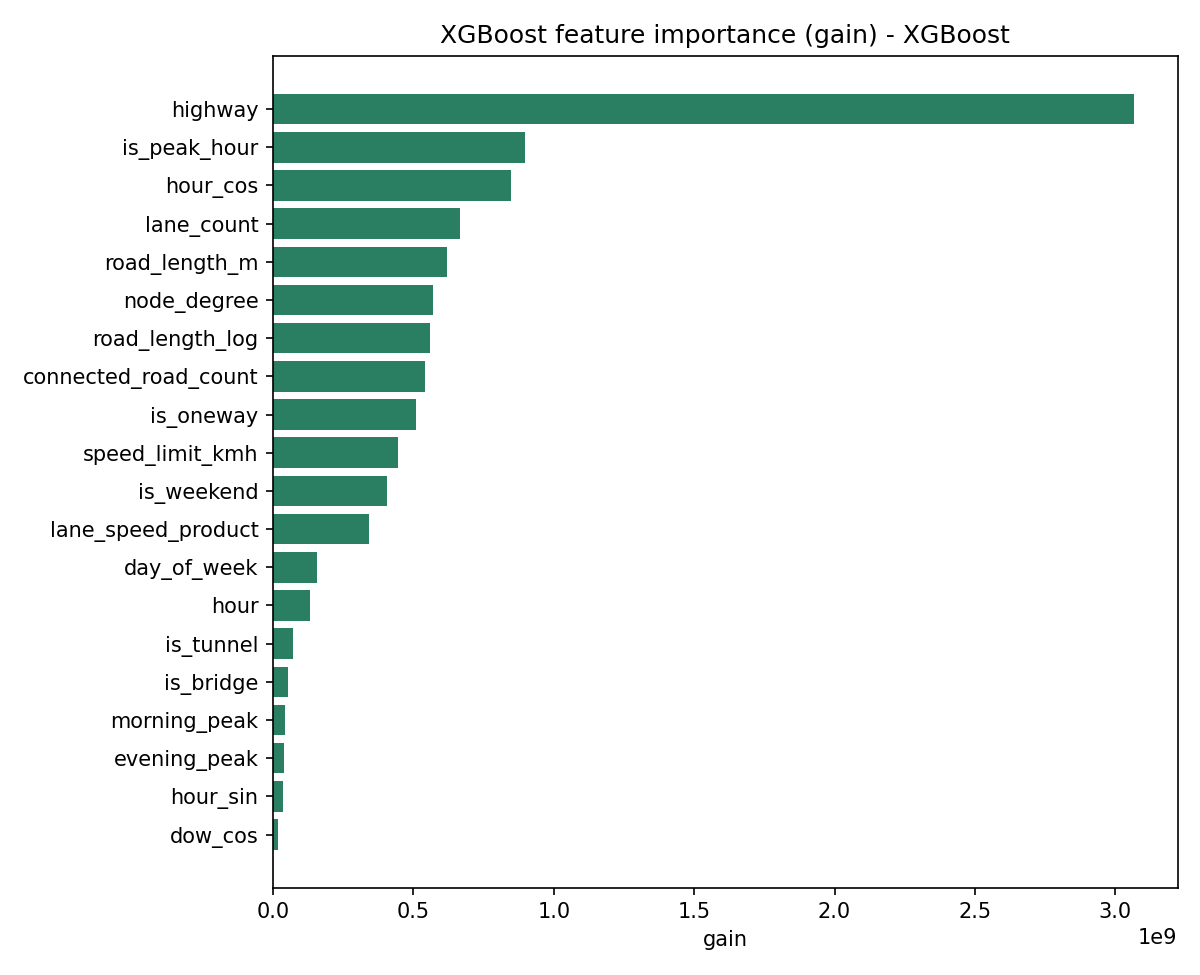

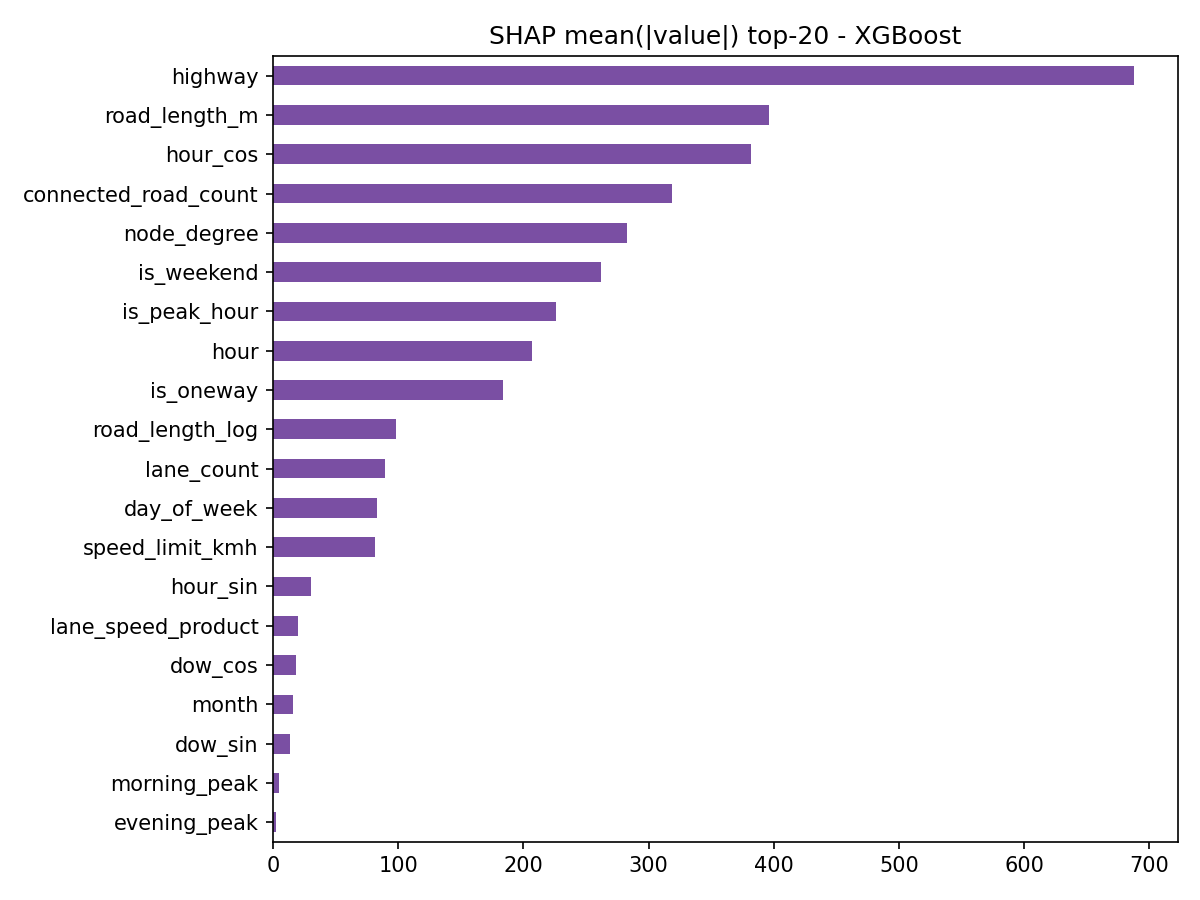

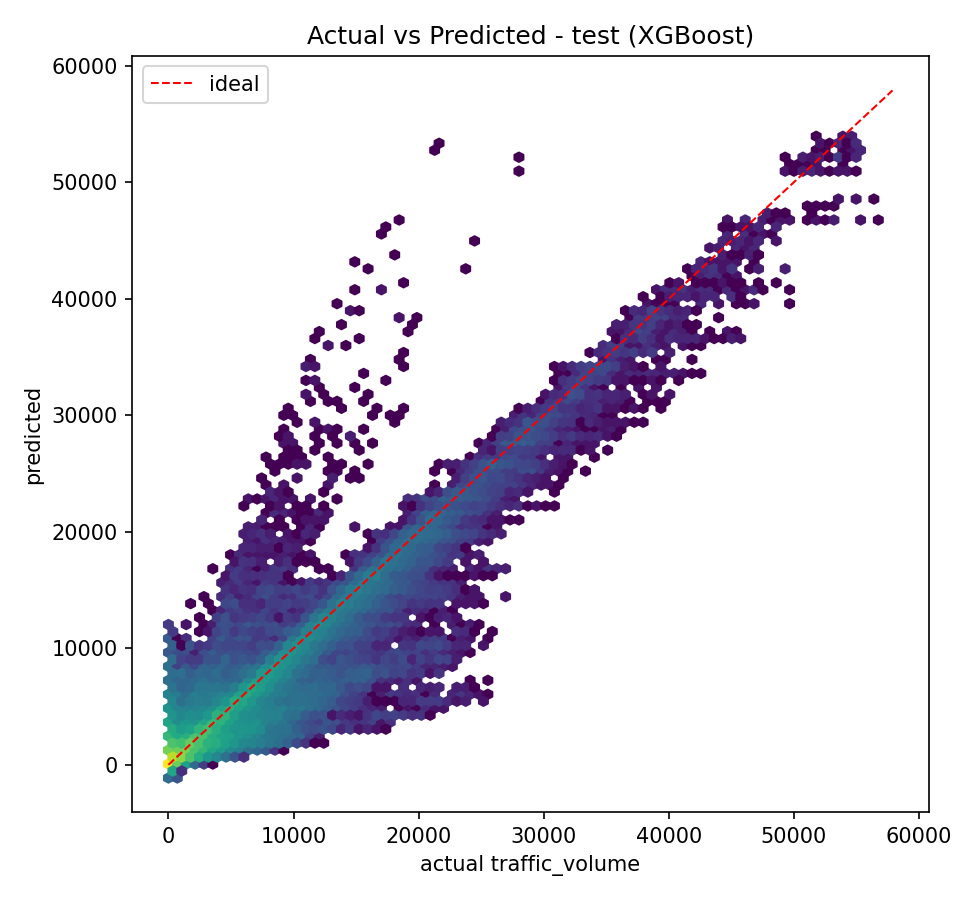

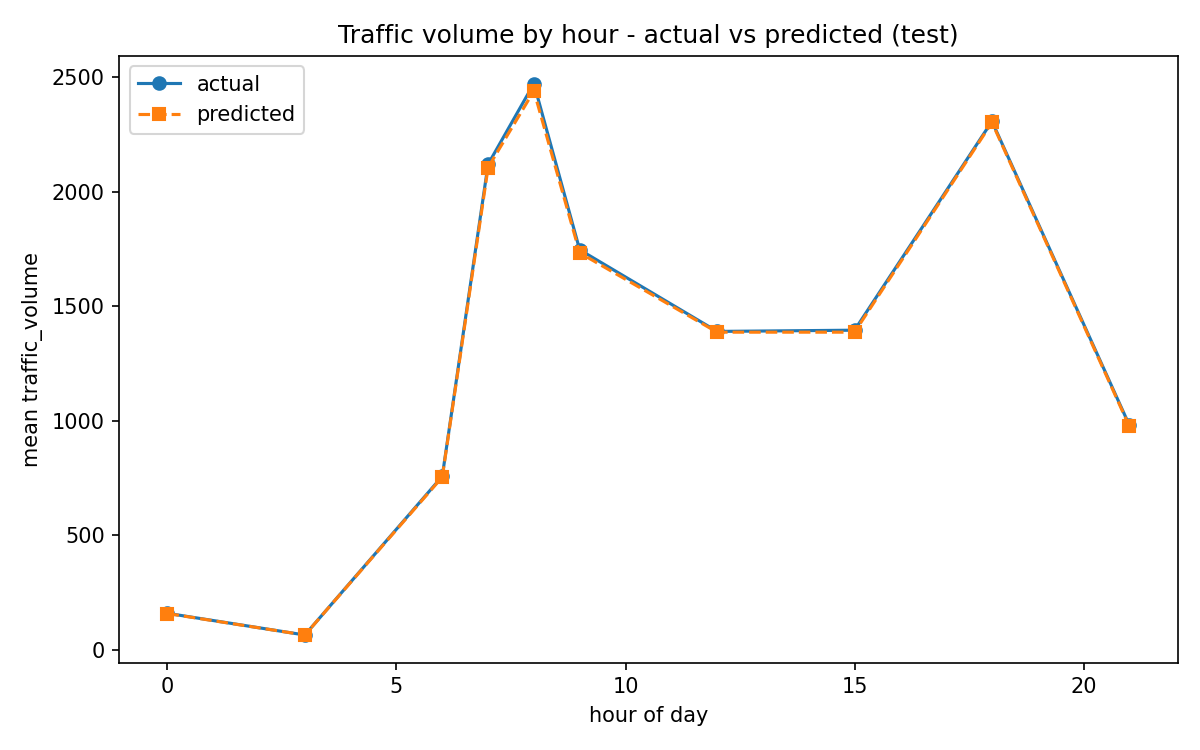

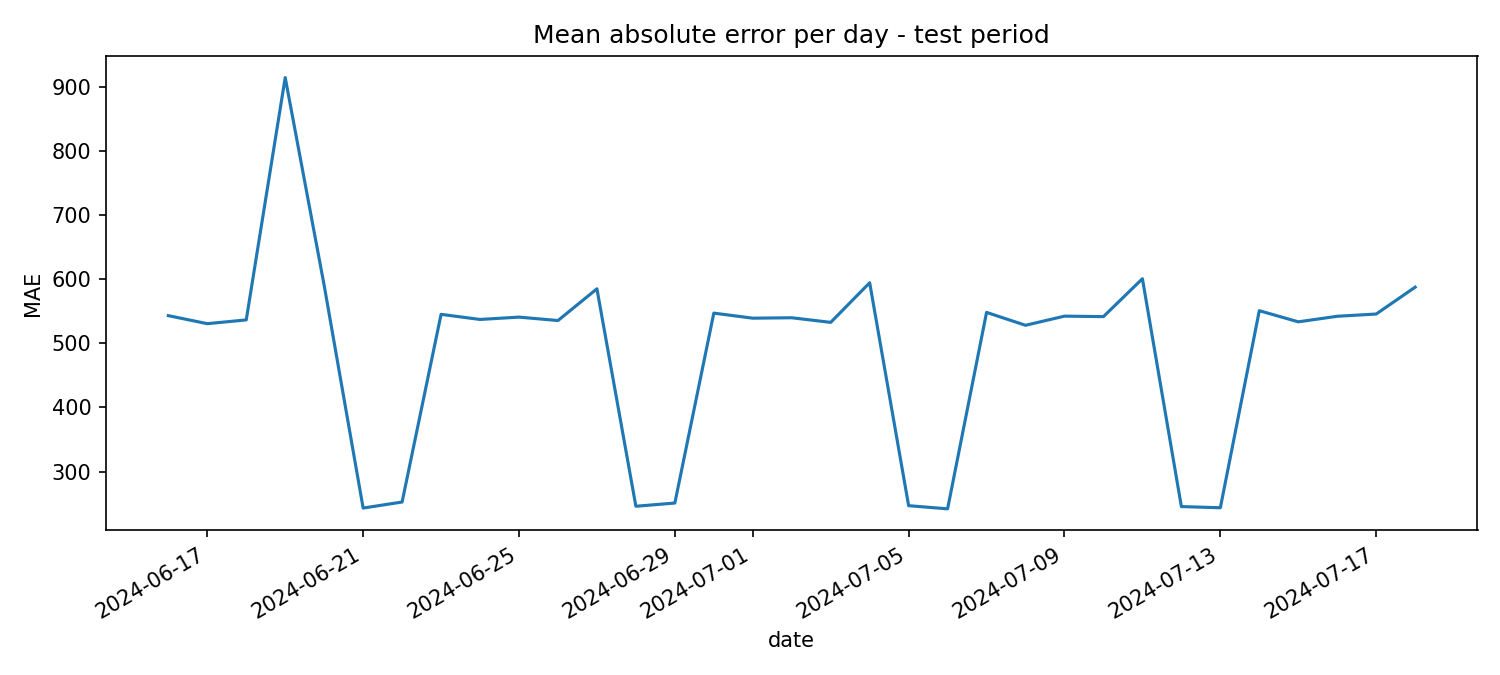

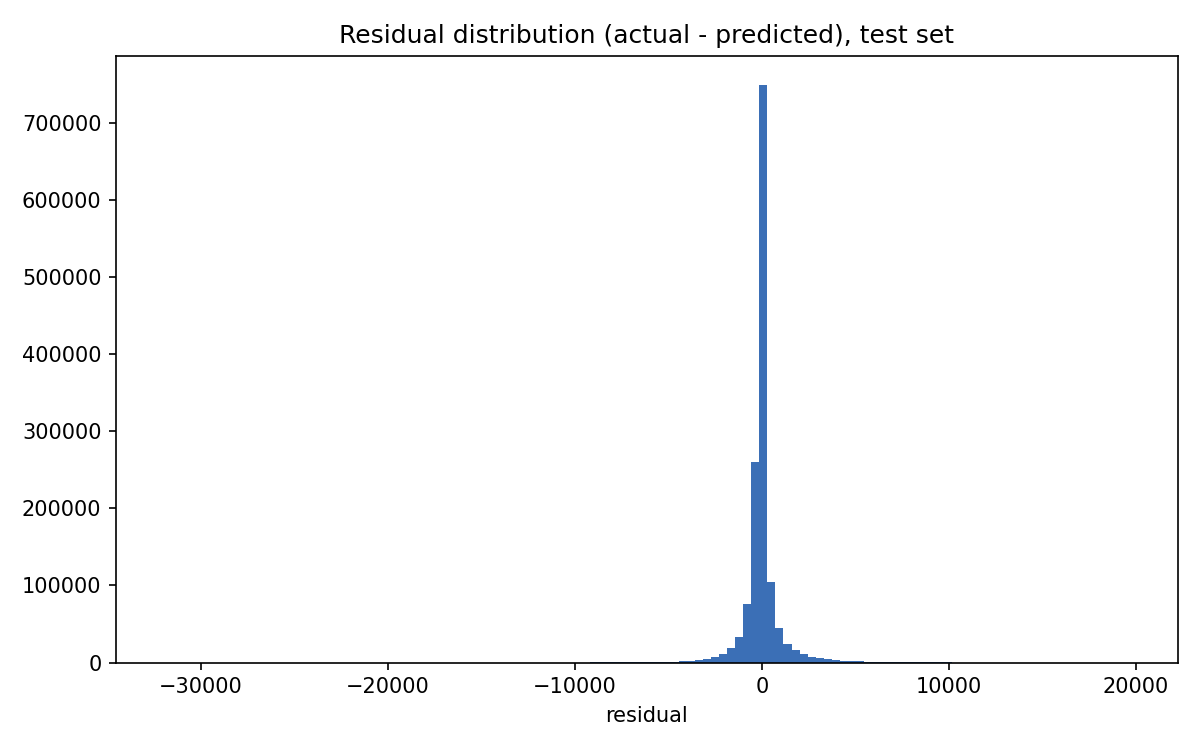

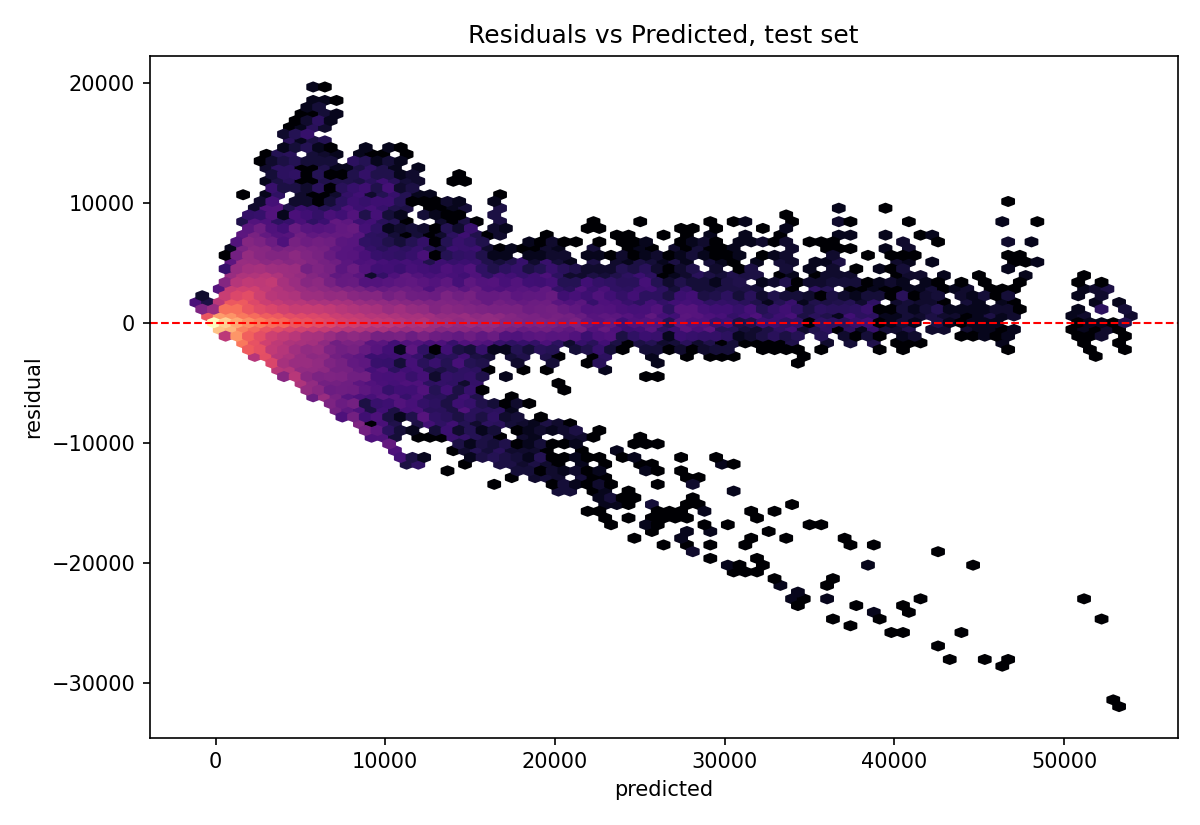

In [7]:
from IPython.display import Image, display
for p in ['feature_importance', 'shap_summary', 'actual_vs_predicted',
          'traffic_by_hour', 'performance_over_time', 'residual_distribution',
          'residual_vs_predicted']:
    display(Image(filename=f'reports/plots/{p}.png', width=640))

## 5. Reload saved model (What-If simulation entry point)

In [8]:
import xgboost as xgb
booster = xgb.Booster()
booster.load_model('models/traffic_xgboost_model.json')
print('model loaded | features:', booster.num_features())

sample = pd.read_parquet('data/processed/traffic_ml_clean.parquet').tail(5)
feats = meta['features']
X = sample[feats].copy()
X['highway'] = X['highway'].astype('category')
pred = booster.inplace_predict(X)
out = sample[['road_id','date','hour']].assign(predicted_volume=pred.round(1),
                                               actual=sample['traffic_volume'])
out

model loaded | features: 22


,road_id,date,hour,predicted_volume,actual
8505995,osm_road_004248,2024-07-18,21,4550.899902,4876
8505996,osm_road_004249,2024-07-18,21,1295.000000,806
8505997,osm_road_004250,2024-07-18,21,384.100006,112
8505998,osm_road_004251,2024-07-18,21,256.700012,387
8505999,osm_road_004252,2024-07-18,21,384.100006,802


**Model artifact:** `models/traffic_xgboost_model.json` + `models/preprocessing_metadata.json` (feature list, category order, split dates, params).